# Normal Distribution — Optimized

This notebook explores the normal distribution on the `ssc_p` column of
the placement dataset: visualizing the distribution, computing probability
over a range via the PDF, the empirical CDF, and standardizing to z-scores.

**What changed from the original version:**
- `sns.distplot` (deprecated, removed in seaborn ≥ 0.14) → `sns.histplot(...,
  kde=True)`.
- `get_pdf_probability()` summed the PDF at each integer in the range as a
  stand-in for an integral (`sum(dist.pdf(v) for v in range(...))`). This is
  an unconventional approximation — it implicitly treats each integer as a
  bin of width 1, which only works because `ssc_p` happens to be on a 0–100
  scale. The correct, scale-independent way to get "the probability mass
  between two values" for a continuous distribution is
  `dist.cdf(end) - dist.cdf(start)`. Both versions are shown below so you
  can compare them.
- `stdNBgraph()` looped in Python to build z-scores one element at a time
  and left in a dead, commented-out `#z_score.std()`. Standardization is now
  vectorized with `(series - mean) / std`, which is both faster and
  unambiguous.
- Single `import` of `seaborn`/`scipy`/`matplotlib` at the top instead of
  re-importing inside every function call.
- Imports moved out of function bodies (importing inside a function is fine
  in Python, but doing it on every call is needless overhead and makes
  dependencies harder to see at a glance).


## 1. Setup & data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from statsmodels.distributions.empirical_distribution import ECDF

sns.set_theme(style="whitegrid")

dataset = pd.read_csv("PrePlacement.csv")
dataset.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

## 2. Visualize the distribution

`sns.distplot` is deprecated and removed in seaborn ≥ 0.14. `sns.histplot`
with `kde=True` is the direct, supported replacement for a histogram +
density-estimate overlay.

C:\Users\Maheshwaran\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


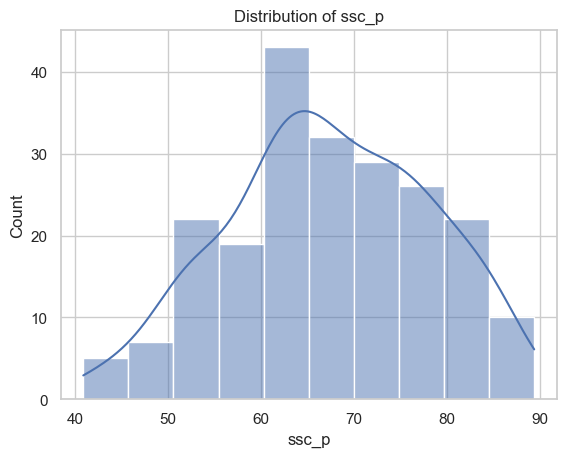

In [2]:
sns.histplot(dataset["ssc_p"], kde=True)
plt.xlabel("ssc_p")
plt.title("Distribution of ssc_p")
plt.show()

## 3. Probability over a range (PDF)

Two ways to estimate "what fraction of the distribution falls between
`startrange` and `endrange`?", assuming the data is normally distributed
with the sample's mean and standard deviation:

1. **Exact (recommended):** `dist.cdf(end) - dist.cdf(start)` — the area
   under the PDF between the two points, computed directly from the CDF.
2. **Riemann-sum approximation (what the original notebook did):** summing
   `dist.pdf(v)` for each integer `v` in the range. This approximates the
   integral using width-1 rectangles and only makes sense when your data's
   natural unit is "1" (as percentages here) — it would silently misbehave
   on differently-scaled data (e.g. salaries), so it's included only for
   comparison.

In [3]:
def plot_with_range(series, start, end):
    """Plot the histogram + KDE for `series` with vertical lines at start/end."""
    sns.histplot(series, kde=True, color="green")
    plt.axvline(start, color="red")
    plt.axvline(end, color="red")
    plt.xlabel(series.name or "value")
    plt.title(f"{series.name}: range [{start}, {end}]")
    plt.show()


def pdf_probability_exact(series, start, end):
    """Exact probability mass in [start, end] assuming a normal fit, via the CDF."""
    mean, std = series.mean(), series.std()
    dist = norm(mean, std)
    prob = dist.cdf(end) - dist.cdf(start)
    print(f"Mean={mean:.3f}, Standard Deviation={std:.3f}")
    print(f"P({start} <= X <= {end}) = {prob:.6f}  (exact, via CDF)")
    return prob


def pdf_probability_riemann(series, start, end):
    """Original approximation: sum of PDF values at each integer in [start, end)."""
    mean, std = series.mean(), series.std()
    dist = norm(mean, std)
    values = range(start, end)
    prob = sum(dist.pdf(v) for v in values)
    print(f"P(approx, width-1 bins) over [{start}, {end}) = {prob:.6f}")
    return prob

C:\Users\Maheshwaran\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


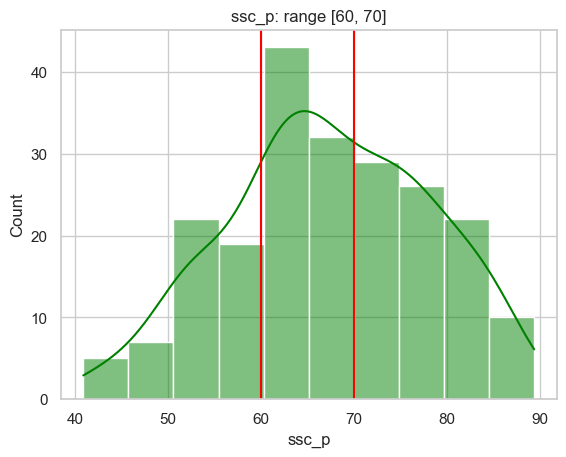

Mean=67.303, Standard Deviation=10.827
P(60 <= X <= 70) = 0.348358  (exact, via CDF)
P(approx, width-1 bins) over [60, 70) = 0.344951

Difference (exact - approx): 0.003407


In [4]:
plot_with_range(dataset["ssc_p"], 60, 70)
exact = pdf_probability_exact(dataset["ssc_p"], 60, 70)
approx = pdf_probability_riemann(dataset["ssc_p"], 60, 70)
print(f"\nDifference (exact - approx): {exact - approx:.6f}")

## 4. Empirical Cumulative Distribution Function (ECDF)

In [5]:
ecdf = ECDF(dataset["ssc_p"])
ecdf(80)  # fraction of observations <= 80

0.8651162790697674

## 5. Standardizing to the Standard Normal Distribution

Converting a variable to z-scores — `(x - mean) / std` — rescales it to
have mean 0 and standard deviation 1, matching the standard normal
distribution. The original looped over every value in Python; pandas/numpy
broadcasting does the same thing in one vectorized expression, which is
both clearer and considerably faster on larger columns.

C:\Users\Maheshwaran\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


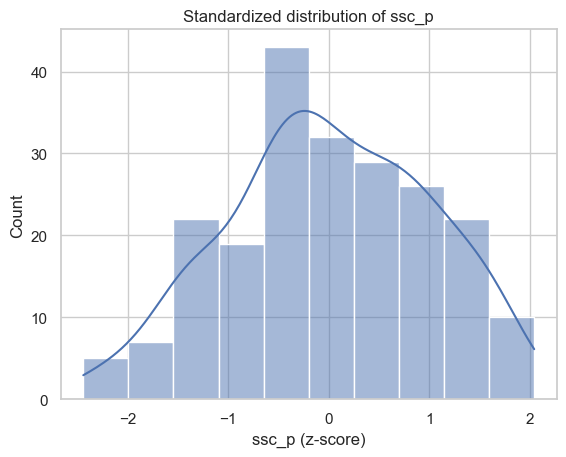

Mean of z-scores : -0.000000  (should be ~0)
Std of z-scores  : 1.000000  (should be ~1)


In [6]:
def to_zscore(series):
    """Vectorized standardization: (x - mean) / std."""
    return (series - series.mean()) / series.std()


def plot_standardized(series):
    z = to_zscore(series)
    sns.histplot(z, kde=True)
    plt.xlabel(f"{series.name} (z-score)")
    plt.title(f"Standardized distribution of {series.name}")
    plt.show()
    print(f"Mean of z-scores : {z.mean():.6f}  (should be ~0)")
    print(f"Std of z-scores  : {z.std():.6f}  (should be ~1)")
    return z

z_scores = plot_standardized(dataset["ssc_p"])